# Ejercicio: clasificación con Keras en CPU
Red neuronal para clasificar flores Iris — sin GPU, sin warnings.

In [ ]:
# Verificar entorno — debe mostrar CPU únicamente
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']  = '3'
os.environ['CUDA_VISIBLE_DEVICES']  = '-1'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['KERAS_BACKEND']         = 'tensorflow'

import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('Dispositivos:', tf.config.list_physical_devices())
print('GPU visible: NO — corriendo en CPU correctamente')

TensorFlow: 2.19.0
Dispositivos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPU visible: NO — corriendo en CPU correctamente


In [ ]:
# 1. Cargar y preparar datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

iris = load_iris()
X, y = iris.data, iris.target

scaler = StandardScaler()
X = scaler.fit_transform(X)
y_cat = keras.utils.to_categorical(y, 3)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)
print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba:        {X_test.shape[0]} muestras')
print(f'Clases:        {iris.target_names}')

Entrenamiento: 120 muestras
Prueba:        30 muestras
Clases:        ['setosa' 'versicolor' 'virginica']


In [ ]:
# 2. Construir la red neuronal
modelo = keras.Sequential([
    keras.layers.Input(shape=(4,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8,  activation='relu'),
    keras.layers.Dense(3,  activation='softmax')
], name='clasificador_iris')

modelo.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
modelo.summary()

Model: "clasificador_iris"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 3. Entrenar
historial = modelo.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.3854 - loss: 1.1587 - val_accuracy: 0.4167 - val_loss: 1.0982
Epoch 2/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4271 - loss: 1.1183 - val_accuracy: 0.5417 - val_loss: 1.0582
Epoch 3/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4479 - loss: 1.0824 - val_accuracy: 0.5833 - val_loss: 1.0208
Epoch 4/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4688 - loss: 1.0491 - val_accuracy: 0.6667 - val_loss: 0.9878
Epoch 5/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4792 - loss: 1.0211 - val_accuracy: 0.6667 - val_loss: 0.9547
Epoch 6/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4583 - loss: 0.9942 - val_accuracy: 0.6667 - val_loss: 0.9261
Epoch 7/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4583 - loss: 0.9710 - val_accuracy: 0.7083 - val_loss: 0.8979
Epoch 8/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4896 - loss: 0.9502 - val_accuracy: 0.7083 - val_loss: 0.8698


Exactitud en prueba: 100.0%


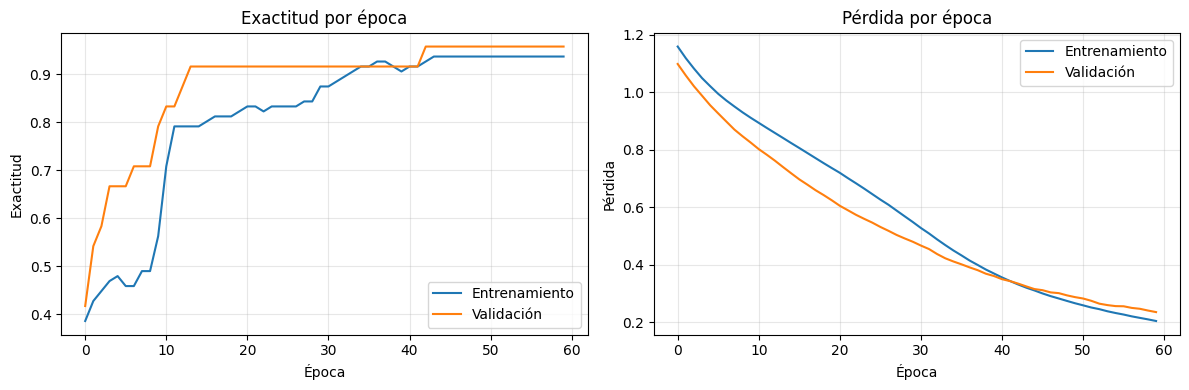

Gráfica guardada como curvas_entrenamiento.png


In [ ]:
# 4. Evaluar y graficar
loss, acc = modelo.evaluate(X_test, y_test, verbose=0)
print(f'Exactitud en prueba: {acc*100:.1f}%')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historial.history['accuracy'],     label='Entrenamiento')
ax1.plot(historial.history['val_accuracy'], label='Validación')
ax1.set_title('Exactitud por época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Exactitud')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(historial.history['loss'],     label='Entrenamiento')
ax2.plot(historial.history['val_loss'], label='Validación')
ax2.set_title('Pérdida por época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Pérdida')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=120)
plt.show()
print('Gráfica guardada como curvas_entrenamiento.png')

In [ ]:
# 5. Predicción con datos nuevos
muestra = np.array([[5.1, 3.5, 1.4, 0.2]])  # Iris setosa típica
muestra_scaled = scaler.transform(muestra)
prediccion = modelo.predict(muestra_scaled, verbose=0)
clase = iris.target_names[np.argmax(prediccion)]

print('Probabilidades por clase:')
for nombre, prob in zip(iris.target_names, prediccion[0]):
    barra = '█' * int(prob * 30)
    print(f'  {nombre:15s} {prob:.3f}  {barra}')
print(f'\nClasificación: {clase}')

Probabilidades por clase:
  setosa          0.966  ████████████████████████████
  versicolor      0.027  
  virginica       0.007  

Clasificación: setosa


### ¿Quieres instalar una librería adicional?
Ejecuta en una celda nueva:
```python
import sys
!{sys.executable} -m pip install --user nombre_libreria
```
Se instala en tu carpeta personal y no afecta a otros usuarios.